# Preload Packages

In [1]:
# Limit number of cores
import os
os.nice(19)
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"
os.environ["OMP_NUM_THREADS"] = "1"

# Create logger
import logging
logger = logging.getLogger(__name__)
logger.setLevel(logging.INFO)

if not logger.hasHandlers():
    ch = logging.StreamHandler()
    formatter = logging.Formatter('%(asctime)s - %(name)s - %(levelname)s - %(message)s')
    ch.setFormatter(formatter)
    logger.addHandler(ch)

In [2]:
import pyccl as ccl
import matplotlib.pyplot as plt
import numpy as np

# Import galaxy alignment predictor
# Add root directory to path
import sys
notebook_dir = os.path.dirname(os.path.abspath("__file__"))
root_dir = os.path.abspath(os.path.join(notebook_dir, '..'))
if root_dir not in sys.path:
    sys.path.append(root_dir)

from src.galaxy_alignment_prediction_tool.predictor import galaxyAlignmentPredictor
from src.galaxy_alignment_prediction_tool.powerspectrum import powerSpectrum

/home/dneup16/.conda/envs/GNAT/lib/python3.12/site-packages/pyccl/background.py:27: UserWarning: A NumPy version >=1.23.5 and <2.5.0 is required for this version of SciPy (detected version 2.5.2)
  from scipy.interpolate import Akima1DInterpolator as interp


# Set simulation settings

In [3]:
# Initialise ccl.Cosmology
import pyccl as ccl
ccl_cosmo = ccl.Cosmology(
    Omega_c=0.27,
    Omega_b=0.045,
    h=0.67,
    n_s=0.96,
    sigma8=0.8,
)

# Define redshifts at which to calculate estimators
redshift_list = np.arange(0, 2.1, 0.5)

# Define scales at which to calculate estimators
rp_array = np.geomspace(0.1, 200, 200)/ccl_cosmo['h']  # in Mpc
r_array = np.geomspace(0.1, 200, 200)/ccl_cosmo['h']  # in Mpc

# Pi_max for projection integrals
pi_max = 50.0/ccl_cosmo['h']  # in Mpc

# Example with included power spectra

2026-09-15 17:06:13,990 - __main__ - INFO - Initialising power spectrum splines for each redshift
100%|██████████| 5/5 [00:00<00:00, 4430.91it/s]
2026-09-15 17:06:13,997 - __main__ - INFO - Done. Splines stored in self.pk_splines_list
2026-09-15 17:06:13,998 - __main__ - INFO - Calculating estimators for each redshift and power spectrum type
100%|██████████| 5/5 [00:00<00:00, 16.68it/s]
2026-09-15 17:06:14,299 - __main__ - INFO - Done calculating estimators. Results stored in self.multipole_splines and self.projection_splines


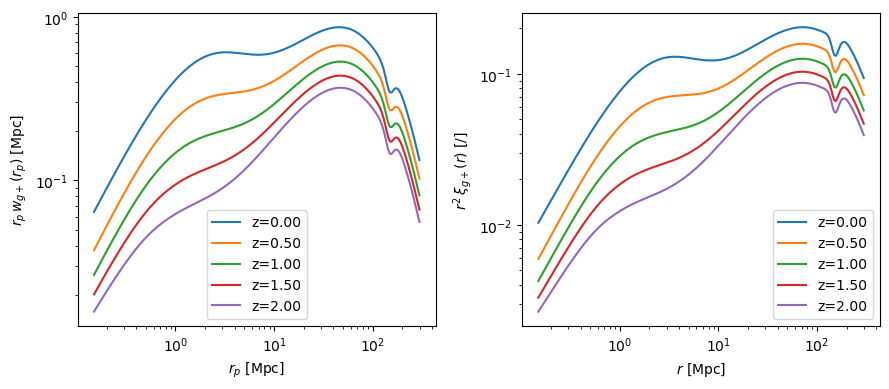

In [4]:
# Initialise class
predictor = galaxyAlignmentPredictor(
    cosmology=ccl_cosmo,
    redshift_list=redshift_list,
    logger=logger,
)

# This function internally compputes splines for g+ and gg power spectrum for each redshift
predictor.initialise_all_power_spectra_from_ccl(
    k_bounds=[1e-6, 1e3], # in 1/Mpc, chosen conservatively to cover all scales
    n_k=5000,
)

# This function function internally computes multipole and projection estimators
predictor.calculate_estimators(
    rp_support=rp_array,
    beta_shape=0, # No RSD, for example in real space
    beta_density=0, # No RSD, for example in real space
    pi_max=pi_max,
)

# Retrieve projection estimators as arrays
w_arr, xi_arr = predictor.return_all_estimators_as_arrays(
    rp_support=rp_array,
    r_support=r_array,
)

# Retrieve splines for projection estimators
# projection_splines is a list of lists of interp1d objects
# Outer list runs over redshifts, inner list over power spectrum types (g+, gg)
projection_splines = predictor.return_projection_splines()
multipole_splines = predictor.return_multipole_splines()

# Example: evaluate w_gp and xi_gp for all redshifts
rp_grid = np.geomspace(0.1, 200, 200)/ccl_cosmo['h']  # in Mpc, from 0.1 to 200 Mpc/h
r_grid = np.geomspace(0.1, 200, 200)/ccl_cosmo['h']  # in Mpc, from 0.1 to 200 Mpc/h

fig, ax = plt.subplots(1, 2, figsize=(9, 4))
for idx_z, z in enumerate(redshift_list):
    w_gp_spline = projection_splines[idx_z][0]  # g+ projection spline
    w_gp_at_rp = w_gp_spline(rp_grid)

    xi_gp_spline = multipole_splines[idx_z][0]  # g+ multipole spline
    xi_gp_at_rp = xi_gp_spline(r_grid)

    ax[0].loglog(rp_grid, rp_grid*w_gp_at_rp, label=f'z={z:.2f}')
    ax[1].loglog(r_grid, r_grid**2 * xi_gp_at_rp, label=f'z={z:.2f}')

ax[0].set_xlabel(r'$r_p$ [Mpc]')
ax[0].set_ylabel(r'$r_p\,w_{g+}(r_p)$ [Mpc]')
ax[0].legend()
ax[1].legend()
ax[1].set_xlabel(r'$r$ [Mpc]')
ax[1].set_ylabel(r'$r^2\,\xi_{g+}(r)$ [/]')
plt.tight_layout()
plt.show()
plt.close()


# Example with custom power spectra

2026-09-15 17:06:14,857 - __main__ - INFO - Initialising power spectrum splines for each redshift
100%|██████████| 5/5 [00:00<00:00, 4022.93it/s]
2026-09-15 17:06:14,861 - __main__ - INFO - Done. Splines stored in self.pk_splines_list
2026-09-15 17:06:14,863 - __main__ - INFO - Calculating estimators for each redshift and power spectrum type
100%|██████████| 5/5 [00:00<00:00, 26.11it/s]
2026-09-15 17:06:15,057 - __main__ - INFO - Done calculating estimators. Results stored in self.multipole_splines and self.projection_splines


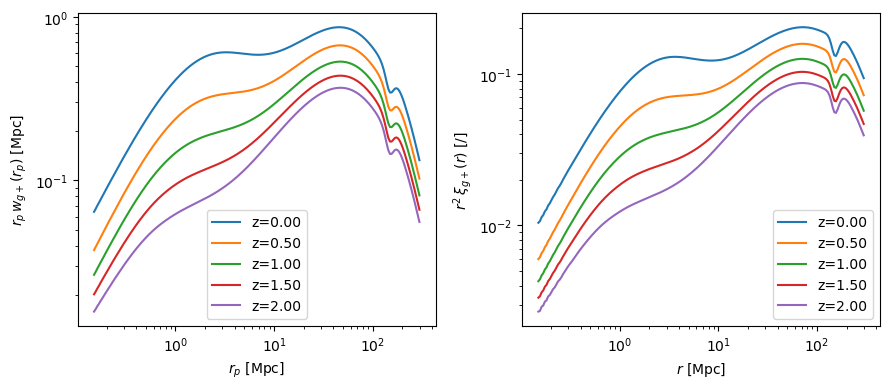

In [5]:
# We need to create k_array and pk_array as np.ndarrays in the format (n_k, n_pk, n_redshifts). 
# We use here the vanilla g+ and gg obtained from the 3d matter power spectrum
k_array_single = np.geomspace(1e-5, 5e2, 1000)  # shape (n_k,)
k_array = np.tile(k_array_single, (len(redshift_list), 2, 1)).T
pk_input = np.zeros((len(k_array_single), 2, len(redshift_list)))  # shape (n_k, n_pk, n_redshifts)

# Fill pk_input with g+ and gg power spectra
powerSpectrumHandler = powerSpectrum()
for idx_z, z in enumerate(redshift_list):
    pkmm_ccl = powerSpectrumHandler.ccl_power_spectrum(
        cosmo=ccl_cosmo,
        k_input=k_array_single,
        redshift=z,
        pk_type='nonlinear_matter'
    )

    # Initialise power spectra
    pkgp = powerSpectrumHandler.convert_pk_matter_to_pk_gplus(
        pk_matter=pkmm_ccl,
        cosmo=ccl_cosmo,
        redshift=z
    )
    pkgg = powerSpectrumHandler.convert_pk_matter_to_pk_gg(
        pk_matter=pkmm_ccl,
        cosmo=ccl_cosmo,
        redshift=z,
        )

    pk_input[:, 0, idx_z] = pkgp
    pk_input[:, 1, idx_z] = pkgg

# Then, we initialise the power spectra in the predictor
predictor = galaxyAlignmentPredictor(
    cosmology=ccl_cosmo,
    redshift_list=redshift_list,
    logger=logger,
)
predictor.initialise_power_spectra(
    k_input=k_array,
    pk_input=pk_input,
    probetype_order = ['g+', 'gg'],
)

# The rest of the procedure is the same as above
predictor.calculate_estimators(
    rp_support=rp_array,
    beta_shape=0, # No RSD, for example in real space
    beta_density=0, # No RSD, for example in real space
    pi_max=pi_max,
)


# Retrieve projection estimators as arrays
w_arr, xi_arr = predictor.return_all_estimators_as_arrays(
    rp_support=rp_array,
    r_support=r_array,
)

# Retrieve splines for projection estimators
# projection_splines is a list of lists of interp1d objects
# Outer list runs over redshifts, inner list over power spectrum types (g+, gg)
projection_splines = predictor.return_projection_splines()
multipole_splines = predictor.return_multipole_splines()

# Example: evaluate w_gp and xi_gp for all redshifts
rp_grid = np.geomspace(0.1, 200, 200)/ccl_cosmo['h']  # in Mpc, from 0.1 to 200 Mpc/h
r_grid = np.geomspace(0.1, 200, 200)/ccl_cosmo['h']  # in Mpc, from 0.1 to 200 Mpc/h

fig, ax = plt.subplots(1, 2, figsize=(9, 4))
for idx_z, z in enumerate(redshift_list):
    w_gp_spline = projection_splines[idx_z][0]  # g+ projection spline
    w_gp_at_rp = w_gp_spline(rp_grid)

    xi_gp_spline = multipole_splines[idx_z][0]  # g+ multipole spline
    xi_gp_at_rp = xi_gp_spline(r_grid)

    ax[0].loglog(rp_grid, rp_grid*w_gp_at_rp, label=f'z={z:.2f}')
    ax[1].loglog(r_grid, r_grid**2 * xi_gp_at_rp, label=f'z={z:.2f}')

ax[0].set_xlabel(r'$r_p$ [Mpc]')
ax[0].set_ylabel(r'$r_p\,w_{g+}(r_p)$ [Mpc]')
ax[0].legend()
ax[1].legend()
ax[1].set_xlabel(r'$r$ [Mpc]')
ax[1].set_ylabel(r'$r^2\,\xi_{g+}(r)$ [/]')
plt.tight_layout()
plt.show()
plt.close()

# Example with flamingo power spectrum

2026-09-15 17:06:15,533 - __main__ - INFO - <KeysViewHDF5 ['Header', 'References', 'z=0.00', 'z=0.05', 'z=0.10', 'z=0.15', 'z=0.20', 'z=0.25', 'z=0.30', 'z=0.35', 'z=0.40', 'z=0.45', 'z=0.50', 'z=0.55', 'z=0.60', 'z=0.65', 'z=0.70', 'z=0.75', 'z=0.80', 'z=0.85', 'z=0.90', 'z=0.95', 'z=1.00', 'z=1.05', 'z=1.10', 'z=1.15', 'z=1.20', 'z=1.25', 'z=1.30', 'z=1.35', 'z=1.40', 'z=1.45', 'z=1.50', 'z=1.55', 'z=1.60', 'z=1.65', 'z=1.70', 'z=1.75', 'z=1.80', 'z=1.85', 'z=1.90', 'z=1.95', 'z=10.00', 'z=10.25', 'z=10.50', 'z=10.75', 'z=11.00', 'z=11.25', 'z=11.50', 'z=11.75', 'z=12.00', 'z=12.50', 'z=13.00', 'z=13.50', 'z=14.00', 'z=14.50', 'z=15.00', 'z=15.50', 'z=16.00', 'z=16.50', 'z=17.00', 'z=17.50', 'z=18.00', 'z=18.50', 'z=19.00', 'z=19.50', 'z=2.00', 'z=2.05', 'z=2.10', 'z=2.15', 'z=2.20', 'z=2.25', 'z=2.30', 'z=2.35', 'z=2.40', 'z=2.45', 'z=2.50', 'z=2.55', 'z=2.60', 'z=2.65', 'z=2.70', 'z=2.75', 'z=2.80', 'z=2.85', 'z=2.90', 'z=2.95', 'z=20.00', 'z=21.00', 'z=22.00', 'z=23.00', 'z=24.00'

100%|██████████| 5/5 [00:00<00:00, 24.07it/s]
2026-09-15 17:06:15,755 - __main__ - INFO - Done calculating estimators. Results stored in self.multipole_splines and self.projection_splines


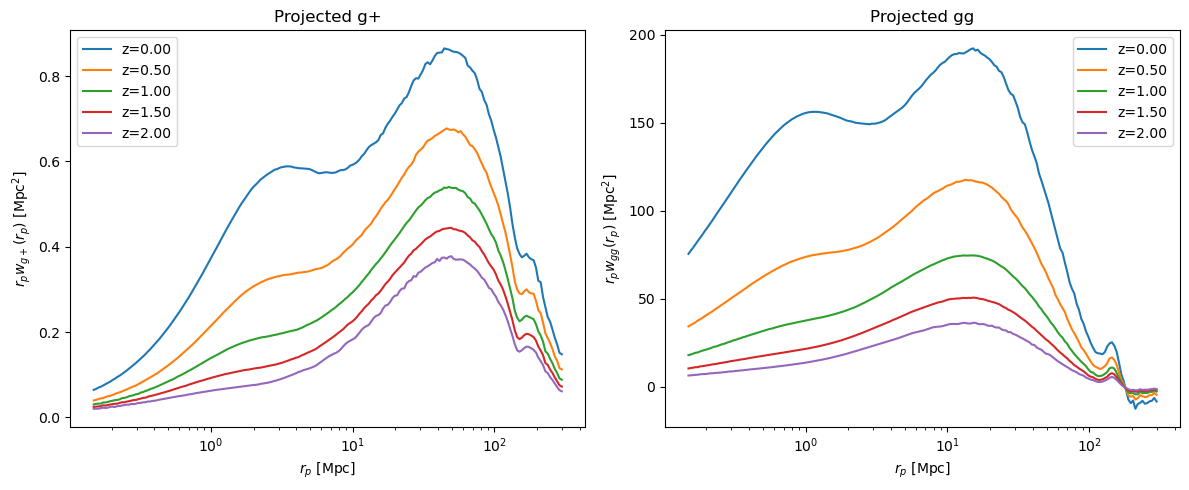

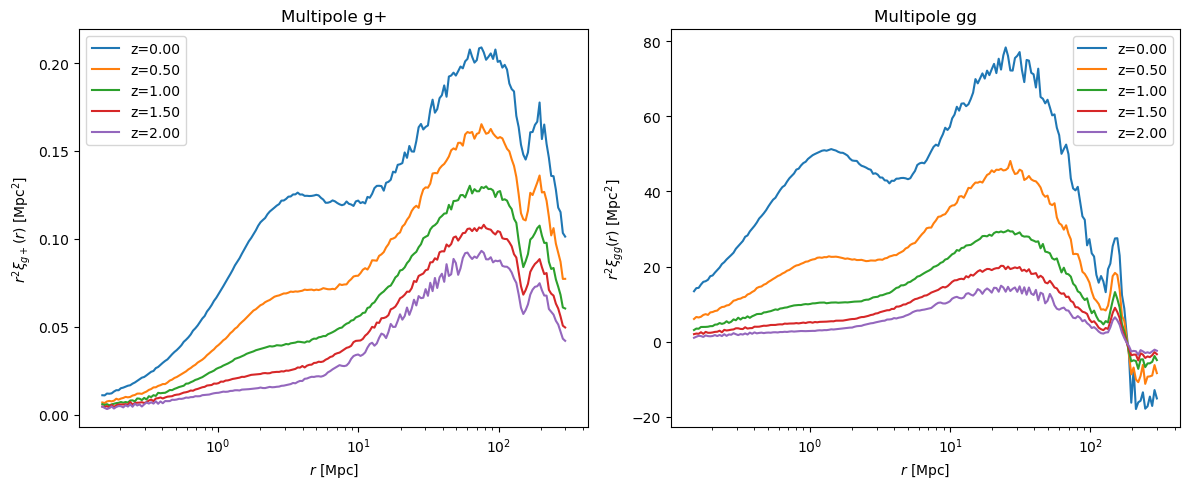

In [6]:
import h5py

# Loading flamingo power spectra
flamingo_pkmm_path = f'{root_dir}/auxdir/spectra/L2p8_m9.hdf5'
redshift_list = np.arange(0, 2.1, 0.5) # Assuming these redshifts are available in flamingo

flamingo_data = h5py.File(flamingo_pkmm_path, 'r')
logger.info(flamingo_data.keys())

# Preload k_z0 to define it as a grid
k_array_single = flamingo_data['z=0.00']['k'][()]

# We need to create k_array and pk_array as np.ndarrays in the format (n_k, n_pk, n_redshifts). 
# We use here the vanilla g+ and gg obtained from the 3d matter power spectrum
k_array = np.tile(k_array_single, (len(redshift_list), 2, 1)).T
pk_input = np.zeros((len(k_array_single), 2, len(redshift_list)))  # shape (n_k, n_pk, n_redshifts)

# Fill pk_input with g+ and gg power spectra
powerSpectrumHandler = powerSpectrum()
for idx_z, z in enumerate(redshift_list):
    flamingo_data_z = flamingo_data[f'z={z:.2f}']

    # Make sure that k_support does not change
    # Otherwise, one would need to interpolate
    assert np.allclose(k_array_single, flamingo_data_z['k'][()])
    pkmm_flamingo = flamingo_data_z['P(k)'][()]

    # Initialise power spectra
    pkgp = powerSpectrumHandler.convert_pk_matter_to_pk_gplus(
        pk_matter=pkmm_flamingo,
        cosmo=ccl_cosmo,
        redshift=z
    )
    pkgg = powerSpectrumHandler.convert_pk_matter_to_pk_gg(
        pk_matter=pkmm_flamingo,
        cosmo=ccl_cosmo,
        redshift=z,
        )

    pk_input[:, 0, idx_z] = pkgp
    pk_input[:, 1, idx_z] = pkgg

# Then, we initialise the power spectra in the predictor
predictor = galaxyAlignmentPredictor(
    cosmology=ccl_cosmo,
    redshift_list=redshift_list,
    logger=logger,
)
predictor.initialise_power_spectra(
    k_input=k_array,
    pk_input=pk_input,
    probetype_order=['g+', 'gg'],
)

# The rest of the procedure is the same as above
predictor.calculate_estimators(
    rp_support=rp_array,
    beta_shape=0, # No RSD, for example in real space
    beta_density=0, # No RSD, for example in real space
    pi_max=pi_max,
)


# Retrieve projection estimators as arrays
w_arr, xi_arr = predictor.return_all_estimators_as_arrays(
    rp_support=rp_array,
    r_support=r_array,
)

# Retrieve splines for projection estimators
# projection_splines is a list of lists of interp1d objects
# Outer list runs over redshifts, inner list over power spectrum types (g+, gg)
projection_splines = predictor.return_projection_splines()

# Retrieve splines for multipole estimators
# Same structure as projection_splines
multipole_splines = predictor.return_multipole_splines()

# Make example plot of w_g+ and w_gg as a function of rp for different redshifts
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
for idx_z, z in enumerate(redshift_list):
    w_gp_spline = projection_splines[idx_z][0]  # g+ projection spline
    w_gg_spline = projection_splines[idx_z][1]  # gg projection spline
    w_gp_at_rp = w_gp_spline(rp_array)
    w_gg_at_rp = w_gg_spline(rp_array)
    axs[0].semilogx(rp_array, rp_array*w_gp_at_rp, label=f'z={z:.2f}')
    axs[1].semilogx(rp_array, rp_array*w_gg_at_rp, label=f'z={z:.2f}')
axs[0].set_xlabel(r'$r_p$ [Mpc]')
axs[0].set_ylabel(r'$r_p w_{g+}(r_p)$ [Mpc$^2$]')
axs[0].set_title('Projected g+')
axs[0].legend()
axs[1].set_xlabel(r'$r_p$ [Mpc]')
axs[1].set_ylabel(r'$r_p w_{gg}(r_p)$ [Mpc$^2$]')
axs[1].set_title('Projected gg')
axs[1].legend()
plt.tight_layout()
plt.show()
plt.close()

# Make example plot of xi_g+ and xi_gg as a function of rp for different redshifts
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
for idx_z, z in enumerate(redshift_list):
    xi_gp_spline = multipole_splines[idx_z][0]  # g+ multipole spline
    xi_gg_spline = multipole_splines[idx_z][1]  # gg multipole spline
    xi_gp_at_r = xi_gp_spline(r_array)
    xi_gg_at_r = xi_gg_spline(r_array)
    axs[0].semilogx(r_array, r_array**2*xi_gp_at_r, label=f'z={z:.2f}')
    axs[1].semilogx(r_array, r_array**2*xi_gg_at_r, label=f'z={z:.2f}')
axs[0].set_xlabel(r'$r$ [Mpc]')
axs[0].set_ylabel(r'$r^2 \xi_{g+}(r)$ [Mpc$^2$]')
axs[0].set_title('Multipole g+')
axs[0].legend()
axs[1].set_xlabel(r'$r$ [Mpc]')
axs[1].set_ylabel(r'$r^2 \xi_{gg}(r)$ [Mpc$^2$]')
axs[1].set_title('Multipole gg')
axs[1].legend()
plt.tight_layout()
plt.show()
plt.close()

In [7]:
import h5py

# Loading flamingo power spectra
flamingo_pkmm_path = f'{root_dir}/auxdir/spectra/L2p8_m9.hdf5'
redshift_list = np.arange(0, 2.1, 0.5) # Assuming these redshifts are available in flamingo

flamingo_data = h5py.File(flamingo_pkmm_path, 'r')
logger.info(flamingo_data.keys())

# Preload k_z0 to define it as a grid
k_array_single = flamingo_data['z=0.00']['k'][()]

# We need to create k_array and pk_array as np.ndarrays in the format (n_k, n_pk, n_redshifts). 
# We use here the vanilla g+ and gg obtained from the 3d matter power spectrum
k_array = np.tile(k_array_single, (len(redshift_list), 2, 1)).T
pk_input = np.zeros((len(k_array_single), 2, len(redshift_list)))  # shape (n_k, n_pk, n_redshifts)

# Fill pk_input with g+ and gg power spectra
powerSpectrumHandler = powerSpectrum()
for idx_z, z in enumerate(redshift_list):
    flamingo_data_z = flamingo_data[f'z={z:.2f}']

    # Make sure that k_support does not change
    # Otherwise, one would need to interpolate
    assert np.allclose(k_array_single, flamingo_data_z['k'][()])
    pkmm_flamingo = flamingo_data_z['P(k)'][()]

    # Initialise power spectra
    pkgp = powerSpectrumHandler.convert_pk_matter_to_pk_gplus(
        pk_matter=pkmm_flamingo,
        cosmo=ccl_cosmo,
        redshift=z
    )
    pkgg = powerSpectrumHandler.convert_pk_matter_to_pk_gg(
        pk_matter=pkmm_flamingo,
        cosmo=ccl_cosmo,
        redshift=z,
        )

    pk_input[:, 0, idx_z] = pkgp
    pk_input[:, 1, idx_z] = pkgg

# Then, we initialise the power spectra in the predictor
predictor = galaxyAlignmentPredictor(
    cosmology=ccl_cosmo,
    redshift_list=redshift_list,
    logger=logger,
)
predictor.initialise_power_spectra(
    k_input=k_array,
    pk_input=pk_input,
    probetype_order=['g+', 'gg'],
)

# The rest of the procedure is the same as above
predictor.calculate_estimators(
    rp_support=rp_array,
    beta_shape=0, # No RSD, for example in real space
    beta_density=0, # No RSD, for example in real space
    pi_max=pi_max,
)


# Retrieve projection estimators as arrays
w_arr, xi_arr = predictor.return_all_estimators_as_arrays(
    rp_support=rp_array,
    r_support=r_array,
)

# Retrieve splines for projection estimators
# projection_splines is a list of lists of interp1d objects
# Outer list runs over redshifts, inner list over power spectrum types (g+, gg)
projection_splines = predictor.return_projection_splines()

# Retrieve splines for multipole estimators
# Same structure as projection_splines
multipole_splines = predictor.return_multipole_splines()

# Make example plot of w_g+ and w_gg as a function of rp for different redshifts
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
for idx_z, z in enumerate(redshift_list):
    w_gp_spline = projection_splines[idx_z][0]  # g+ projection spline
    w_gg_spline = projection_splines[idx_z][1]  # gg projection spline
    w_gp_at_rp = w_gp_spline(rp_array)
    w_gg_at_rp = w_gg_spline(rp_array)
    axs[0].semilogx(rp_array, rp_array*w_gp_at_rp, label=f'z={z:.2f}')
    axs[1].semilogx(rp_array, rp_array*w_gg_at_rp, label=f'z={z:.2f}')
axs[0].set_xlabel(r'$r_p$ [Mpc]')
axs[0].set_ylabel(r'$r_p w_{g+}(r_p)$ [Mpc$^2$]')
axs[0].set_title('Projected g+')
axs[0].legend()
axs[1].set_xlabel(r'$r_p$ [Mpc]')
axs[1].set_ylabel(r'$r_p w_{gg}(r_p)$ [Mpc$^2$]')
axs[1].set_title('Projected gg')
axs[1].legend()
plt.tight_layout()
plt.show()
plt.close()

# Make example plot of xi_g+ and xi_gg as a function of rp for different redshifts
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
for idx_z, z in enumerate(redshift_list):
    xi_gp_spline = multipole_splines[idx_z][0]  # g+ multipole spline
    xi_gg_spline = multipole_splines[idx_z][1]  # gg multipole spline
    xi_gp_at_r = xi_gp_spline(r_array)
    xi_gg_at_r = xi_gg_spline(r_array)
    axs[0].semilogx(r_array, r_array**2*xi_gp_at_r, label=f'z={z:.2f}')
    axs[1].semilogx(r_array, r_array**2*xi_gg_at_r, label=f'z={z:.2f}')
axs[0].set_xlabel(r'$r$ [Mpc]')
axs[0].set_ylabel(r'$r^2 \xi_{g+}(r)$ [Mpc$^2$]')
axs[0].set_title('Multipole g+')
axs[0].legend()
axs[1].set_xlabel(r'$r$ [Mpc]')
axs[1].set_ylabel(r'$r^2 \xi_{gg}(r)$ [Mpc$^2$]')
axs[1].set_title('Multipole gg')
axs[1].legend()
plt.tight_layout()
plt.show()
plt.close()

2026-09-15 16:48:41,291 - __main__ - INFO - <KeysViewHDF5 ['Header', 'References', 'z=0.00', 'z=0.05', 'z=0.10', 'z=0.15', 'z=0.20', 'z=0.25', 'z=0.30', 'z=0.35', 'z=0.40', 'z=0.45', 'z=0.50', 'z=0.55', 'z=0.60', 'z=0.65', 'z=0.70', 'z=0.75', 'z=0.80', 'z=0.85', 'z=0.90', 'z=0.95', 'z=1.00', 'z=1.05', 'z=1.10', 'z=1.15', 'z=1.20', 'z=1.25', 'z=1.30', 'z=1.35', 'z=1.40', 'z=1.45', 'z=1.50', 'z=1.55', 'z=1.60', 'z=1.65', 'z=1.70', 'z=1.75', 'z=1.80', 'z=1.85', 'z=1.90', 'z=1.95', 'z=10.00', 'z=10.25', 'z=10.50', 'z=10.75', 'z=11.00', 'z=11.25', 'z=11.50', 'z=11.75', 'z=12.00', 'z=12.50', 'z=13.00', 'z=13.50', 'z=14.00', 'z=14.50', 'z=15.00', 'z=15.50', 'z=16.00', 'z=16.50', 'z=17.00', 'z=17.50', 'z=18.00', 'z=18.50', 'z=19.00', 'z=19.50', 'z=2.00', 'z=2.05', 'z=2.10', 'z=2.15', 'z=2.20', 'z=2.25', 'z=2.30', 'z=2.35', 'z=2.40', 'z=2.45', 'z=2.50', 'z=2.55', 'z=2.60', 'z=2.65', 'z=2.70', 'z=2.75', 'z=2.80', 'z=2.85', 'z=2.90', 'z=2.95', 'z=20.00', 'z=21.00', 'z=22.00', 'z=23.00', 'z=24.00'

ValueError: A value (1e-05) in x_new is below the interpolation range's minimum value (0.002863650784176).